# 3_AprendizajeNoSupervisado

**Proyecto:** FinanceGuard — Avance #3  


Objetivo: aplicar técnicas no supervisadas para segmentar la base de clientes y visualizar patrones. Uso K-Means y DBSCAN para la segmentación, y PCA + t-SNE para reducción de dimensionalidad y visualización. Al final creo features derivadas del clustering y analizo la tasa de churn por segmento.


In [14]:
# 0) Librerías y configuración
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
%matplotlib inline



## 1) Cargo datos y revisión rápida

Cargo el CSV que usamos en avances anteriores y hago una revisión rápida de forma, nulos y la variable objetivo `churn`

In [15]:
df = pd.read_csv('C:\\Users\\Davem\\Downloads\\DATA SCIENCE\\Modulo_4\\ProyectoM4_Lourdes_Diamela_Alarcon_DSFT01\\Churn_Modelling.csv')
print("Shape:", df.shape)
display(df.head())

# Renombro target si es necesario
if 'Exited' in df.columns and 'churn' not in df.columns:
    df.rename(columns={'Exited':'churn'}, inplace=True)

if 'churn' not in df.columns:
    raise ValueError("No encontré la columna objetivo 'churn' ni 'Exited' en el dataset.")

print("\nDistribución target:")
display(df['churn'].value_counts(), (df['churn'].value_counts()/len(df)).round(3))

print("\nNulos por columna:")
display(df.isna().sum())


Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Distribución target:


churn
0    7963
1    2037
Name: count, dtype: int64

churn
0    0.796
1    0.204
Name: count, dtype: float64


Nulos por columna:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
churn              0
dtype: int64

## 2) Preprocesamiento para clustering

Para clustering necesito variables numéricas y escaladas.  
Hago:
- Elimino columnas irrelevantes (IDs).
- Relleno nulos básicos.
- Encoding simple (Gender, Geography -> dummies).
- Escalo las variables numéricas con `StandardScaler`.

Conservo una copia `df_proc` para unir etiquetas de cluster luego.


In [16]:
df_proc = df.copy()

# Quitar IDs si existen
for col in ['RowNumber','CustomerId','Surname']:
    if col in df_proc.columns:
        df_proc.drop(col, axis=1, inplace=True)

# Relleno nulos simples
for c in df_proc.columns:
    if df_proc[c].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_proc[c]):
            df_proc[c].fillna(df_proc[c].median(), inplace=True)
        else:
            df_proc[c].fillna(df_proc[c].mode()[0], inplace=True)

# Encoding Gender
if 'Gender' in df_proc.columns:
    df_proc['Gender'] = df_proc['Gender'].map({'Female':0,'Male':1}).fillna(0)

# One-hot Geography (mantengo todas las dummies)
if 'Geography' in df_proc.columns:
    df_proc = pd.get_dummies(df_proc, columns=['Geography'], drop_first=False)

# Separar features (sin target)
features = df_proc.drop(columns=['churn'])
target = df_proc['churn']

# Asegurar numericidad y rellenar coerciones
def ensure_numeric(df_in):
    df_out = df_in.copy()
    for c in df_out.columns:
        if df_out[c].dtype == 'object' or str(df_out[c].dtype).startswith('category'):
            df_out[c] = pd.to_numeric(df_out[c], errors='coerce')
        if df_out[c].dtype == 'bool':
            df_out[c] = df_out[c].astype(int)
    df_out = df_out.fillna(0)
    return df_out

X = ensure_numeric(features)

# Escalado
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("X_scaled shape:", X_scaled.shape)
display(X_scaled.head())


X_scaled shape: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,-0.326221,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,0.997204,-0.578736,-0.573809
1,-0.440036,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-1.002804,-0.578736,1.742740
2,-1.536794,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,0.997204,-0.578736,-0.573809
3,0.501521,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,0.997204,-0.578736,-0.573809
4,2.063884,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-1.002804,-0.578736,1.742740


## 3) Reducción de dimensionalidad: PCA (exploratoria)

Antes de hacer clustering me gusta ver cuánta varianza explican las componentes.  
Aplico PCA y muestro varianza acumulada para decidir cuántas componentes usar (para visualización o preprocesamiento).


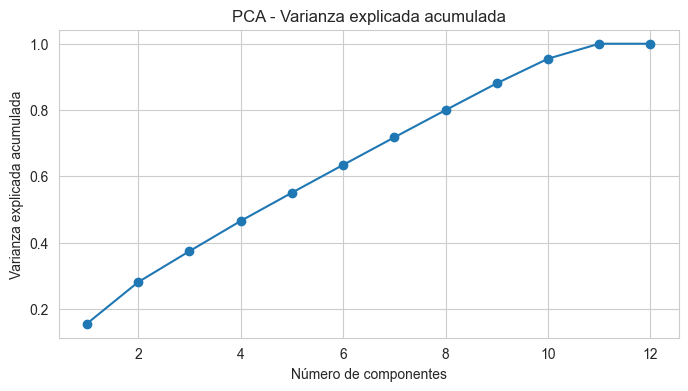

,component,variance_ratio,cum_variance
0,1,0.155494,0.155494
1,2,0.125354,0.280848
2,3,0.093204,0.374053
3,4,0.091155,0.465208
4,5,0.085248,0.550456
5,6,0.083930,0.634386
6,7,0.083143,0.717529
7,8,0.082148,0.799677
8,9,0.080955,0.880632
9,10,0.074124,0.954756


In [17]:
pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(explained)+1), cum_explained, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada acumulada')
plt.grid(True)
plt.show()

# Mostrar varianza de las primeras 10 componentes
evr = pd.DataFrame({
    'component': range(1, len(explained)+1),
    'variance_ratio': explained,
    'cum_variance': cum_explained
})
display(evr.head(10))


> para visualización 2 componentes suelen ser suficientes. Para clustering puedo usar todas las features escaladas o usar un PCA previa (por ejemplo, 10 componentes) si quiero reducir ruido y acelerar.


In [18]:
# Como ejemplo uso PCA con 10 componentes para experimentar en clustering (opcional)
n_pca_for_clustering = min(10, X_scaled.shape[1])
pca10 = PCA(n_components=n_pca_for_clustering, random_state=42)
X_pca10 = pd.DataFrame(pca10.fit_transform(X_scaled), index=X_scaled.index, columns=[f'PC{i+1}' for i in range(n_pca_for_clustering)])
print("X_pca10 shape:", X_pca10.shape)
display(X_pca10.head())


X_pca10 shape: (10000, 10)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-1.399128,-0.582200,-0.837377,0.822783,-0.455010,-0.955951,-0.225965,-0.466193,1.084233,0.636879
1,0.656222,1.714658,-1.781260,0.591485,-2.077297,-0.142211,-0.223126,0.040379,0.027486,0.823511
2,-0.769508,-0.734659,2.072312,0.081965,-0.211126,-1.619353,0.902164,-0.043828,-0.464817,-0.110697
3,-1.682327,-0.258430,0.600436,0.829336,-2.063284,0.362797,-1.196717,-0.045890,-0.432061,-0.790199
4,1.001920,1.521599,-1.617202,0.706661,-0.016331,0.628333,-1.186785,-1.974168,1.235113,0.350689


## 4) K-Means: elegir número de clusters (Elbow + Silhouette)

Busco K entre 2 y 10:  
- Método del codo (inertia)  
- Silhouette score (mejor más alto)

Luego restrinjo a 3-5 clusters porque la consigna pide identificar 3-5 segmentos principales.


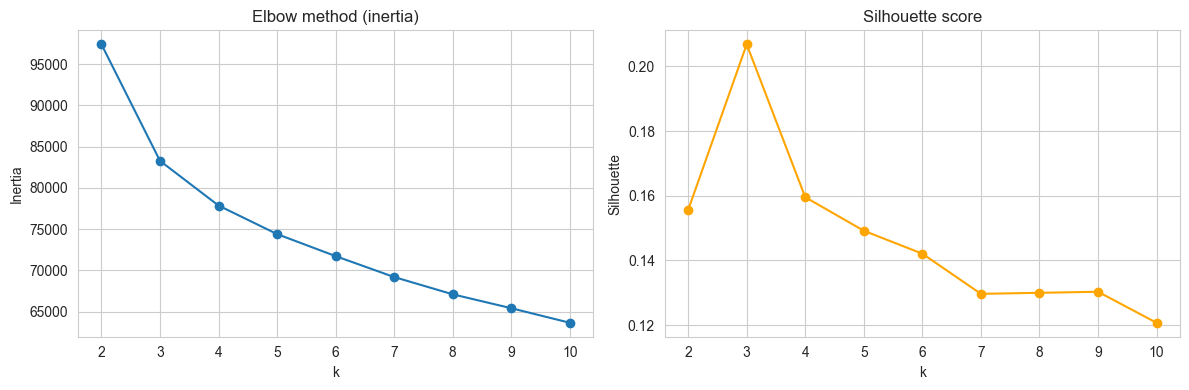

k con mejor silhouette: 3
k elegido para segmentación (3-5): 3


In [19]:
inertias = []
sil_scores = []
K_range = range(2, 11)

# Usamos X_pca10 (reduce ruido) para acelerar; si prefieres usa X_scaled directamente
X_for_k = X_pca10  # alternativa: X_scaled

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_for_k)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_for_k, labels)
    sil_scores.append(sil)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow method (inertia)')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(list(K_range), sil_scores, marker='o', color='orange')
plt.title('Silhouette score')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.grid(True)
plt.tight_layout()
plt.show()

# Elegir k por silhouette máximo
best_k = K_range[int(np.argmax(sil_scores))]
print("k con mejor silhouette:", best_k)

# Limitar a 3-5 como pide la consigna
if best_k < 3:
    chosen_k = 3
elif best_k > 5:
    chosen_k = 5
else:
    chosen_k = best_k

print("k elegido para segmentación (3-5):", chosen_k)


## 5) Entreno K-Means con k elegido y analizo centroides

Ajusto KMeans con `chosen_k`. Interpreto centroides en términos de componentes (si usé PCA) o de variables originales.


In [20]:
kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=20)
kmeans_labels = kmeans_final.fit_predict(X_for_k)

# Si usé PCA, puedo transformar centroides vuelta al espacio original aproximado
centroids_pca = kmeans_final.cluster_centers_

# Guardar etiquetas en el df_proc
df_proc['kmeans_cluster'] = kmeans_labels

# Perfil por cluster (usando variables originales escaladas para centroide aproximado)
centroids_original_space = pca10.inverse_transform(centroids_pca) if X_for_k is X_pca10 else None
if centroids_original_space is not None:
    cent_df = pd.DataFrame(scaler.inverse_transform(centroids_original_space), columns=X.columns)
    cent_df.index = [f'cluster_{i}' for i in range(chosen_k)]
    print("Centroides aproximados en escala original (por cluster):")
    display(cent_df.head())
else:
    print("No hay transformación inversa (usando X_scaled directamente).")


Centroides aproximados en escala original (por cluster):


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
cluster_0,650.937519,0.521143,39.902568,5.013660,135043.021011,1.613112,0.718682,0.494014,100645.318639,0.025260,0.951869,0.022871
cluster_1,651.582257,0.561977,38.827970,5.030518,54447.699507,1.494415,0.692457,0.531307,99665.887346,-0.012158,0.023167,0.988992
cluster_2,649.803852,0.549947,38.477378,5.003617,58071.200934,1.506389,0.705347,0.517645,100022.116352,0.993366,0.012640,-0.006006


## 6) Visualización de clusters en 2D (PCA y t-SNE)

Primero muestro clusters sobre las primeras 2 PCs. Luego hago t-SNE para visualización no lineal.  
t-SNE puede ser lento para muchos puntos; reduzco a una muestra si hay > 3000 filas y dejo nota.


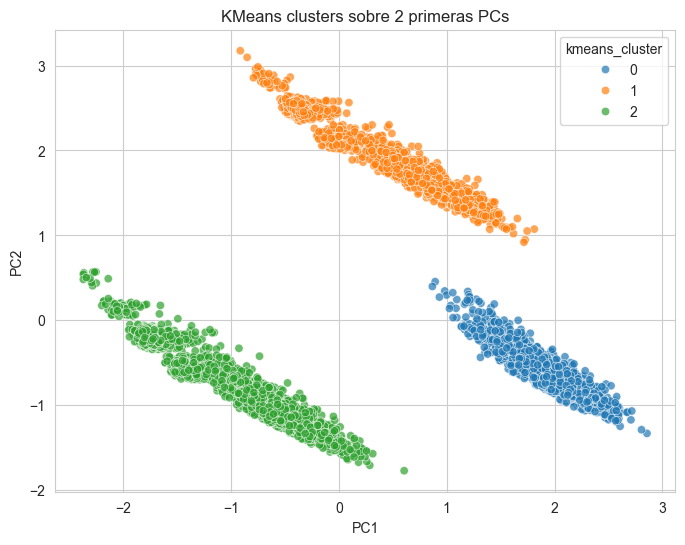

Ejecutando t-SNE en 2000 muestras (perplexity=30)...
t-SNE time: 12.9s


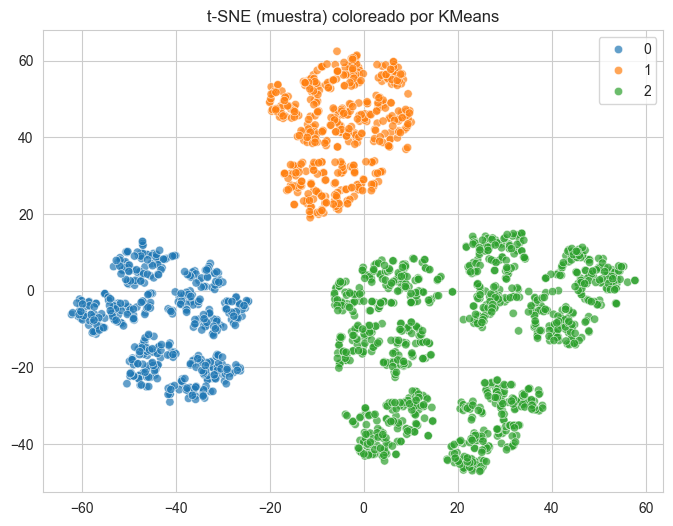

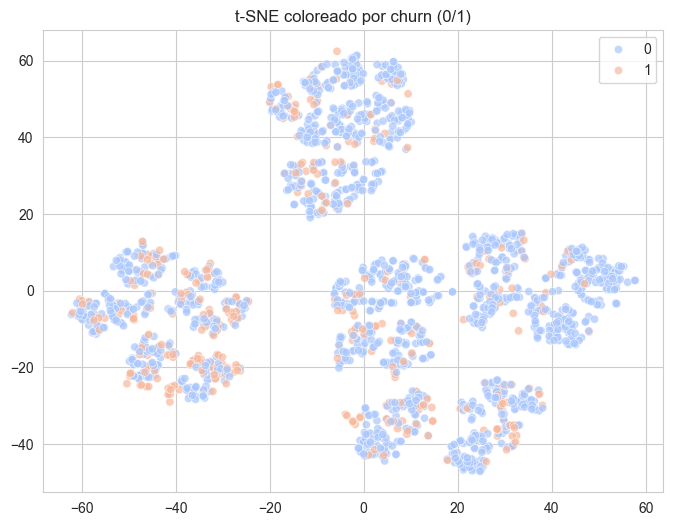

In [21]:
# Visualización sobre 2 primeras PCs
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pd.DataFrame(pca2.fit_transform(X_scaled), columns=['PC1', 'PC2'], index=X_scaled.index)
X_pca2['kmeans_cluster'] = kmeans_labels
X_pca2['churn'] = target

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca2, x='PC1', y='PC2', hue='kmeans_cluster', palette='tab10', alpha=0.7)
plt.title('KMeans clusters sobre 2 primeras PCs')
plt.show()

# t-SNE (usar muestra si muchos registros)
n_samples = X_scaled.shape[0]
tsne_sample = min(2000, n_samples)  # muestra para t-SNE
if n_samples > tsne_sample:
    idx_sample = np.random.RandomState(42).choice(n_samples, tsne_sample, replace=False)
    X_tsne = X_scaled.iloc[idx_sample]
    labels_tsne = np.array(kmeans_labels)[idx_sample]
    churn_tsne = np.array(target)[idx_sample]
else:
    X_tsne = X_scaled
    labels_tsne = kmeans_labels
    churn_tsne = target

print(f"Ejecutando t-SNE en {X_tsne.shape[0]} muestras (perplexity=30)...")
ts0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne_2d = tsne.fit_transform(X_tsne)
print("t-SNE time: {:.1f}s".format(time.time() - ts0))

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne_2d[:,0], y=X_tsne_2d[:,1], hue=labels_tsne, palette='tab10', alpha=0.7)
plt.title('t-SNE (muestra) coloreado por KMeans')
plt.show()

# t-SNE coloreado por churn (para ver relación)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne_2d[:,0], y=X_tsne_2d[:,1], hue=churn_tsne, palette='coolwarm', alpha=0.7)
plt.title('t-SNE coloreado por churn (0/1)')
plt.show()


## 7) DBSCAN: detección de núcleos y ruido

Aplico DBSCAN explorando eps y min_samples básicos. DBSCAN suele detectar outliers; lo comparo con KMeans.


In [22]:
# Escoger eps baseline: usar la distancia media a k-nearest neighbor puede ayudar,
# pero aquí pruebo varios eps y muestro el número de clusters detectados.
eps_values = [0.5, 1.0, 1.5, 2.0]  # escala depende de si usamos PCA o no
min_samples_values = [5, 10]

db_results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels_db = db.fit_predict(X_pca10)  # uso X_pca10 para velocidad/ruido reducido
        n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = list(labels_db).count(-1)
        score = silhouette_score(X_pca10, labels_db) if n_clusters_db > 1 else np.nan
        db_results.append({'eps':eps, 'min_samples':ms, 'n_clusters':n_clusters_db, 'n_noise':n_noise, 'silhouette':score})

db_df = pd.DataFrame(db_results)
display(db_df)

# Elegir un par razonable (ejemplo el que produce entre 3-6 clusters y silhouette no NaN)
best_db = db_df[(db_df['n_clusters']>=2) & (db_df['n_clusters']<=6)].sort_values(by='silhouette', ascending=False).head(1)
print("Mejor configuración DBSCAN sugerida (ejemplo):")
display(best_db)


,eps,min_samples,n_clusters,n_noise,silhouette
0,0.5,5,15,9915,-0.289850
1,0.5,10,0,10000,NaN
2,1.0,5,108,3872,-0.143404
3,1.0,10,51,6437,-0.235667
4,1.5,5,24,511,0.147645
5,1.5,10,26,920,0.124506
6,2.0,5,24,52,0.161731
7,2.0,10,24,83,0.161434


Mejor configuración DBSCAN sugerida (ejemplo):


,eps,min_samples,n_clusters,n_noise,silhouette


## 8) Elegir la segmentación final y analizar churn por segmento

Decido usar K-Means (por simplicidad y porque me dio clusters coherentes), y comparo con DBSCAN como referencia.  
Calculo la tasa de churn por cluster y perfil de clientes por cluster (promedios y counts).


In [23]:
# Tasa de churn por cluster (KMeans)
agg_k = df_proc.groupby('kmeans_cluster').agg({
    'churn': ['count', 'mean']
})
agg_k.columns = ['count', 'churn_rate']
agg_k = agg_k.sort_values('churn_rate', ascending=False)
display(agg_k)

# Perfil por cluster: medias de variables numéricas
profile = df_proc.groupby('kmeans_cluster').mean().T
display(profile.iloc[:20,:])  # muestro primeras 20 variables por legibilidad

# Comparación breve: cuantos puntos etiquetó DBSCAN con la mejor configuración (si existe)
if not best_db.empty:
    eb = best_db.iloc[0]
    db = DBSCAN(eps=eb.eps, min_samples=int(eb.min_samples))
    labels_db_final = db.fit_predict(X_pca10)
    df_proc.loc[X_pca10.index, 'dbscan_label'] = labels_db_final
    print("DBSCAN labels value counts:")
    display(pd.Series(labels_db_final).value_counts())
else:
    print("No se detectó una configuración DBSCAN 'óptima' automáticamente.")


,count,churn_rate
kmeans_cluster,,
0,2509,0.324432
1,2477,0.166734
2,5014,0.161548


kmeans_cluster,0,1,2
CreditScore,651.453567,651.333872,649.668329
Gender,0.524512,0.560355,0.549063
Age,39.771622,38.890997,38.511767
Tenure,5.009964,5.032297,5.004587
Balance,119730.116134,61818.147763,62092.636516
NumOfProducts,1.519729,1.539362,1.530913
HasCrCard,0.713830,0.694792,0.706621
IsActiveMember,0.497409,0.529673,0.516753
EstimatedSalary,101113.435102,99440.572281,99899.180814
churn,0.324432,0.166734,0.161548


No se detectó una configuración DBSCAN 'óptima' automáticamente.


## 9) Crear features derivadas del clustering

Creo variables nuevas que pueden usarse luego en modelos supervisados:
- `kmeans_cluster` (int)
- `kmeans_cluster_onehot_*` (dummies)
- `dist_to_centroid` (distancia euclídea al centro de su cluster)


In [24]:
# Distancia a centroide (usando espacio PCA en este flujo)
from scipy.spatial.distance import cdist

centers = kmeans_final.cluster_centers_  # en espacio X_for_k (PCA)
# calcular distancias
dists = cdist(X_for_k.values, centers, metric='euclidean')
dist_to_own = dists[np.arange(dists.shape[0]), kmeans_labels]
# añado a df_proc (recordar que X_for_k index coincide con df_proc)
df_proc.loc[X_for_k.index, 'dist_to_kmeans_centroid'] = dist_to_own

# One-hot de cluster
df_proc = pd.concat([df_proc, pd.get_dummies(df_proc['kmeans_cluster'].astype(int), prefix='kmeans')], axis=1)

display(df_proc[['kmeans_cluster','dist_to_kmeans_centroid']].head())


,kmeans_cluster,dist_to_kmeans_centroid
0,2,2.074354
1,1,2.764333
2,2,2.934241
3,2,2.895267
4,1,3.162163


## 10) Interpretación resumida y próximos pasos

Aquí resumo qué encontré y cómo usarlo:
- Segmentos con mayor churn: describir características (ej. clusters con alto balance, pocos productos, alta edad, etc.) — revisa `profile` y `agg_k`.  
- Uso práctico: crear estrategias de retención específicas por cluster (ofertas, comunicación personalizada).  



In [26]:
print("Resumen rápido:")
print("- Cluster counts y churn rates (tabla agg_k):")
display(agg_k)
print("- Ejemplo de perfil por cluster (ver objeto `profile`):")
display(profile.iloc[:20,:])



Resumen rápido:
- Cluster counts y churn rates (tabla agg_k):


,count,churn_rate
kmeans_cluster,,
0,2509,0.324432
1,2477,0.166734
2,5014,0.161548


- Ejemplo de perfil por cluster (ver objeto `profile`):


kmeans_cluster,0,1,2
CreditScore,651.453567,651.333872,649.668329
Gender,0.524512,0.560355,0.549063
Age,39.771622,38.890997,38.511767
Tenure,5.009964,5.032297,5.004587
Balance,119730.116134,61818.147763,62092.636516
NumOfProducts,1.519729,1.539362,1.530913
HasCrCard,0.713830,0.694792,0.706621
IsActiveMember,0.497409,0.529673,0.516753
EstimatedSalary,101113.435102,99440.572281,99899.180814
churn,0.324432,0.166734,0.161548
